In [1]:
!pip install --quiet pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 30.5 MB/s eta 0:00:00


Epoch 1 Complete


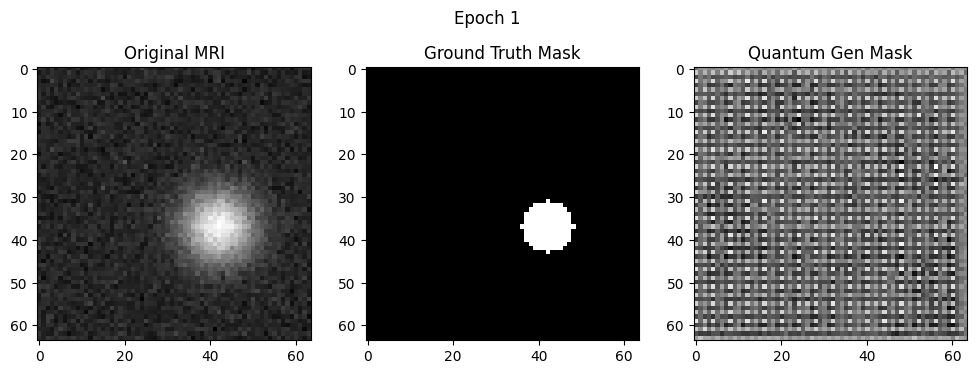

Epoch 2 Complete


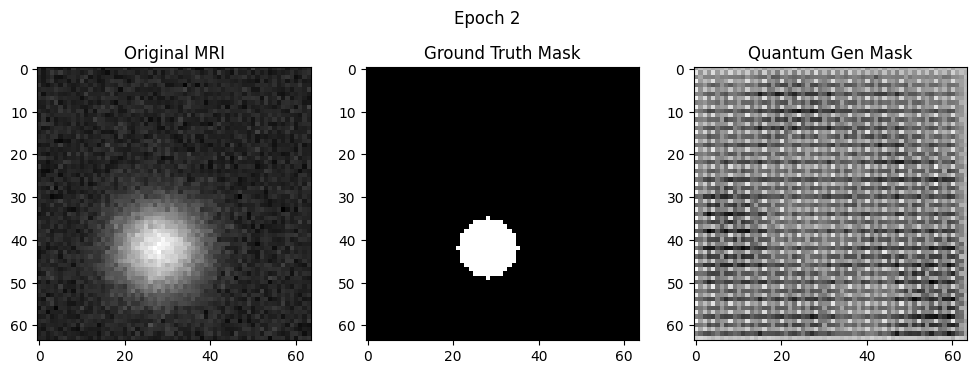

Epoch 3 Complete


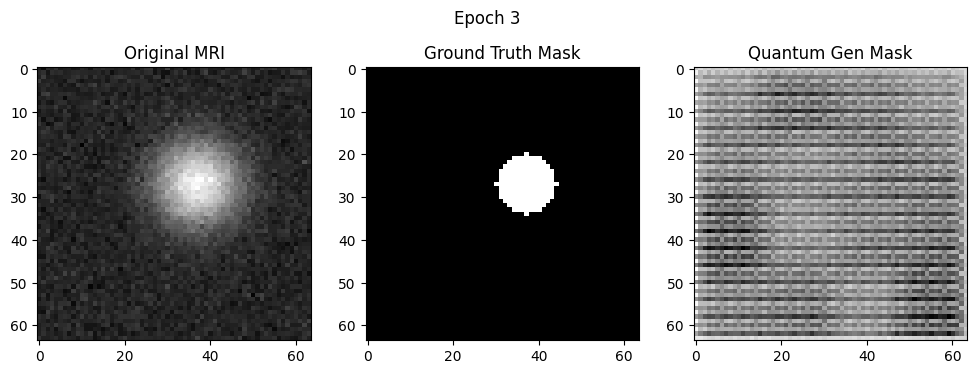

Epoch 4 Complete


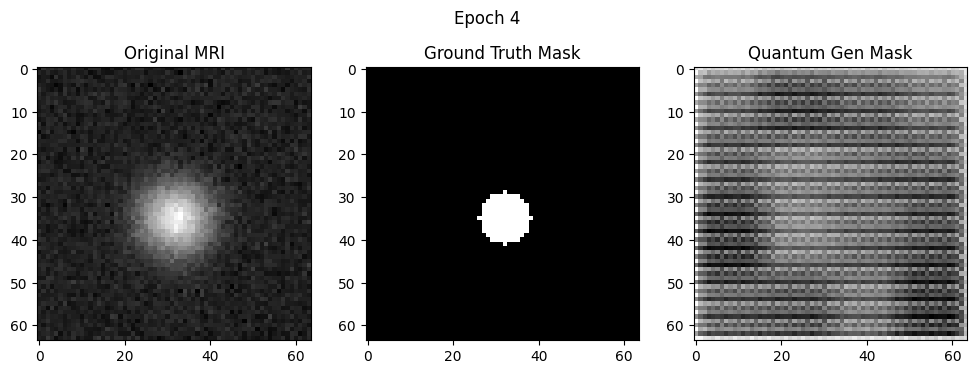

Epoch 5 Complete


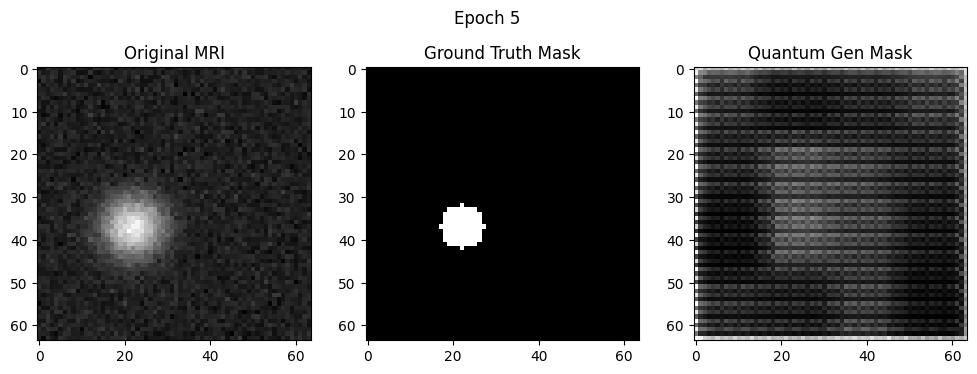

Epoch 6 Complete


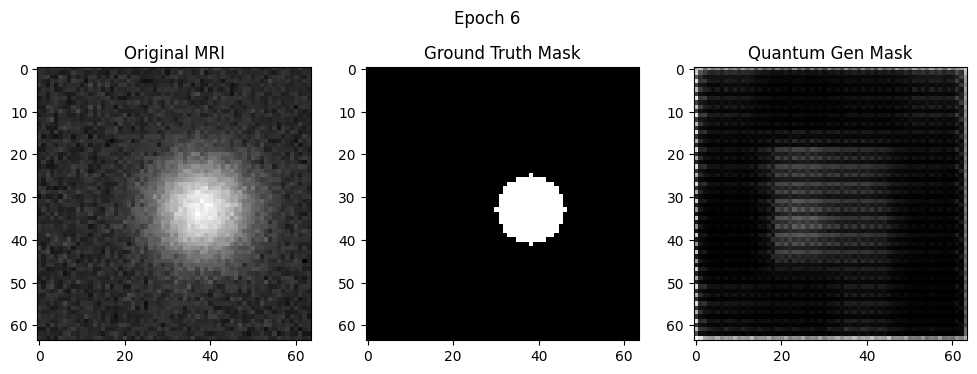

Epoch 7 Complete


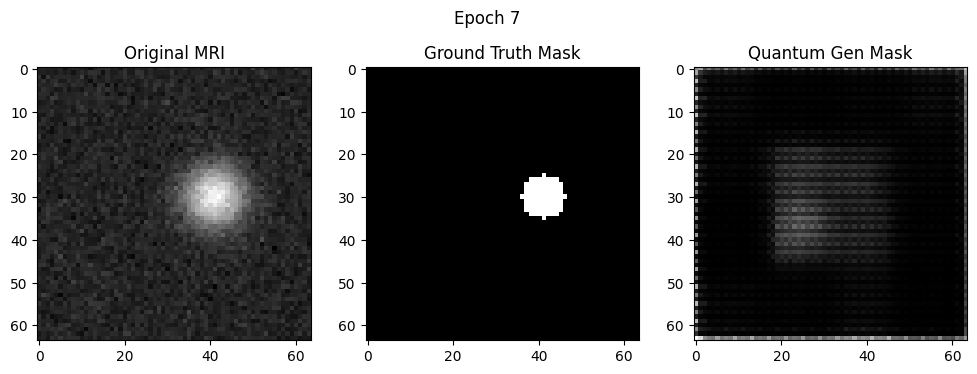

Epoch 8 Complete


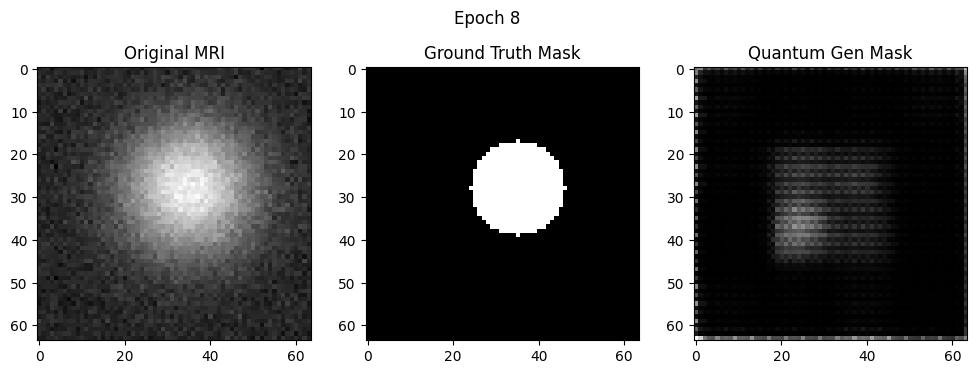

Epoch 9 Complete


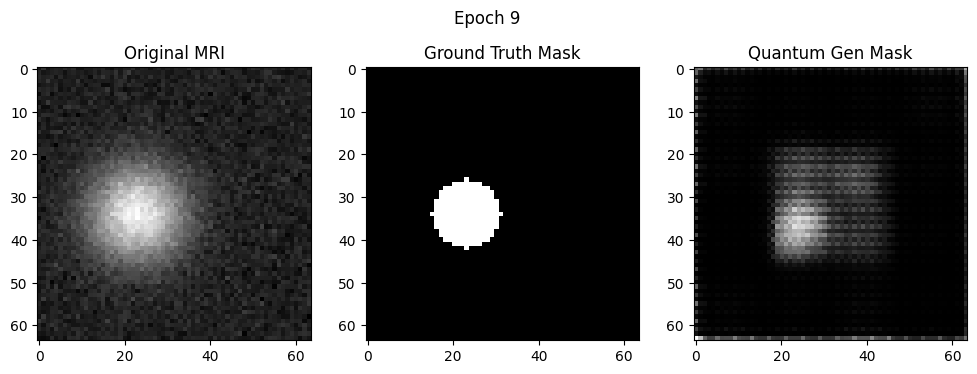

Epoch 10 Complete


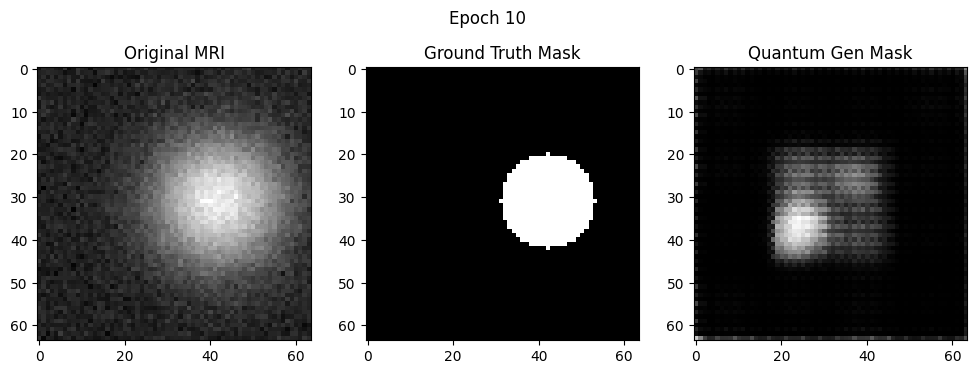

Epoch 11 Complete


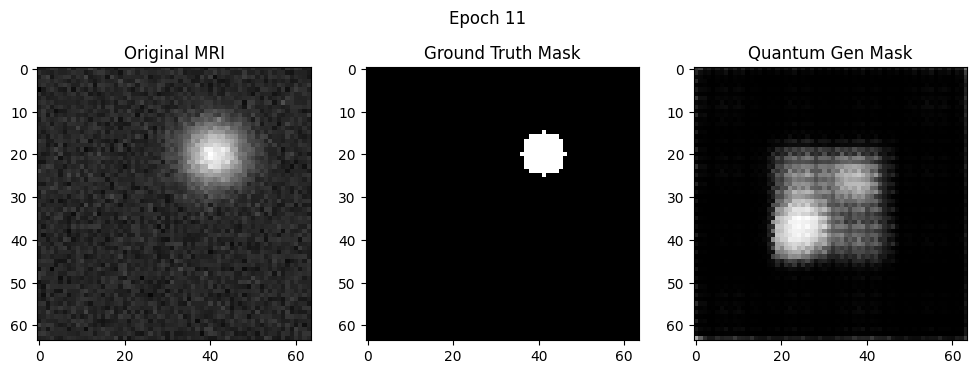

Epoch 12 Complete


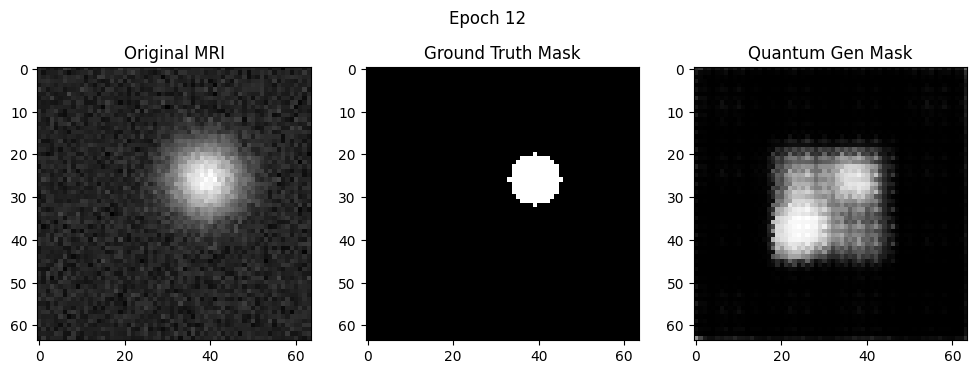

Epoch 13 Complete


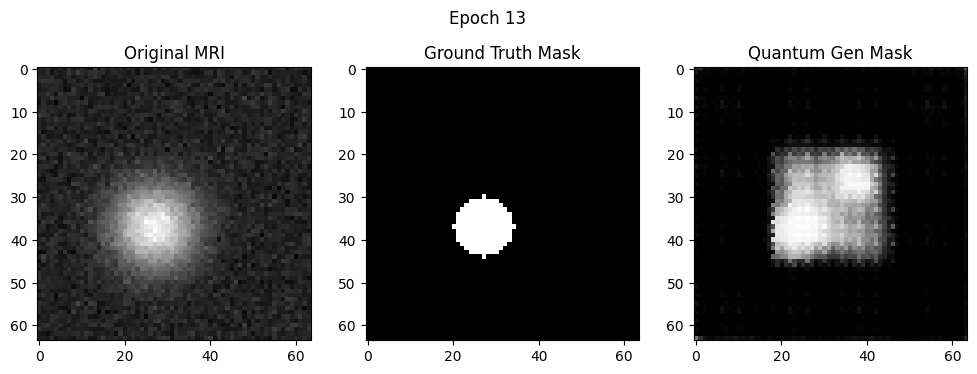

Epoch 14 Complete


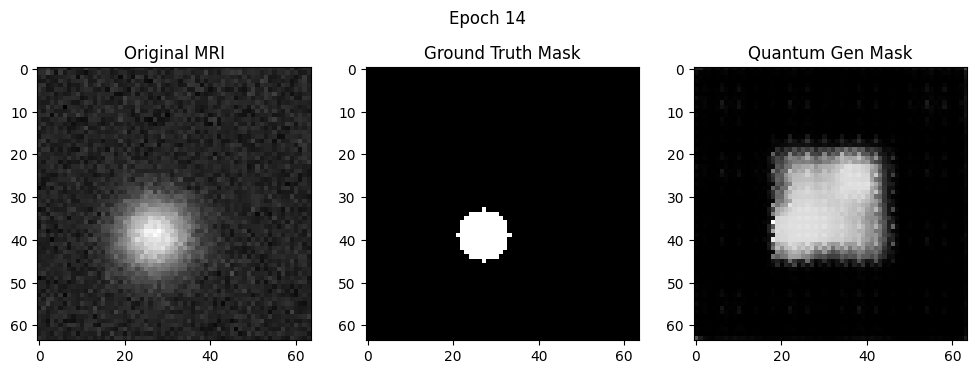

Epoch 15 Complete


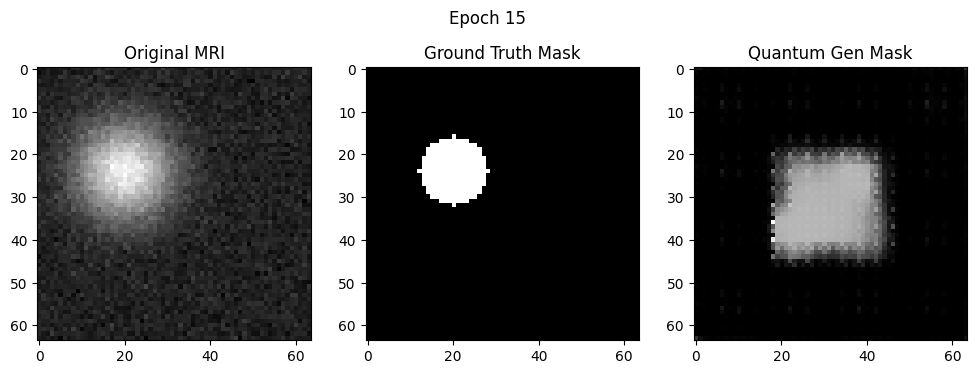

Epoch 16 Complete


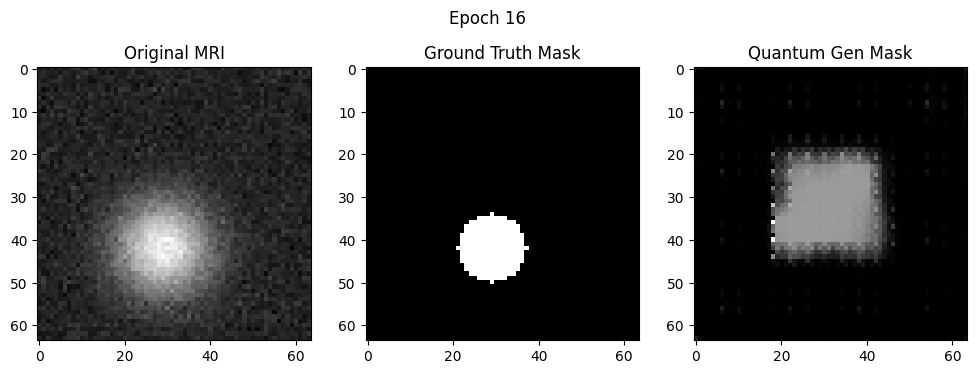

Epoch 17 Complete


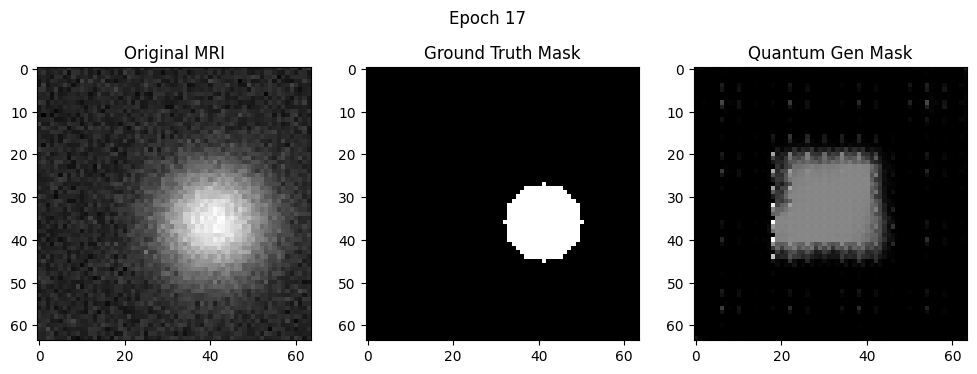

Epoch 18 Complete


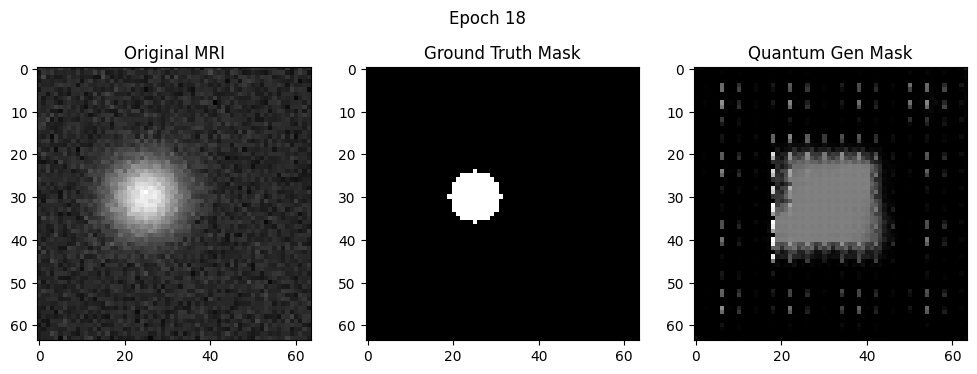

Epoch 19 Complete


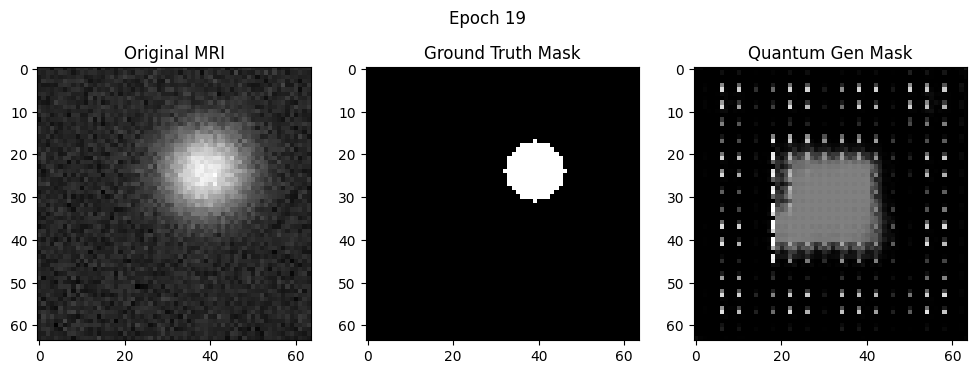

Epoch 20 Complete


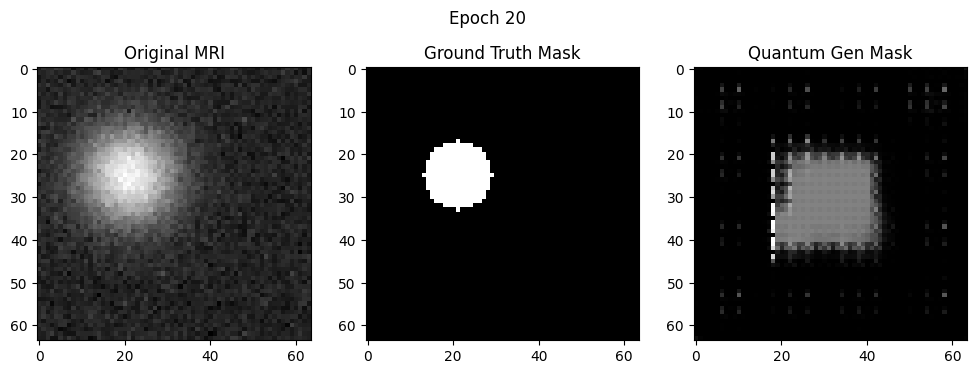

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Quantum Bottleneck (Density Matrix)
# ==========================================
n_qubits = 4
dev = qml.device("default.mixed", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def noisy_quantum_circuit(inputs, weights):
    # inputs shape is [batch_size, n_qubits]
    for i in range(n_qubits):
        qml.RX(inputs[:, i], wires=i)

    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))

    # Noise simulating T1/T2 relaxation
    for i in range(n_qubits):
        qml.DepolarizingChannel(0.01, wires=i)

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

weight_shapes = {"weights": (3, n_qubits, 3)}
quantum_layer = qml.qnn.TorchLayer(noisy_quantum_circuit, weight_shapes)

# ==========================================
# 2. Hybrid Generator & Discriminator
# ==========================================
class HybridGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=4, stride=2, padding=1), # 32x32
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=1), # 16x16
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=4, padding=0), # 4x4
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, n_qubits),
            nn.Tanh()
        )
        self.quantum_bottleneck = quantum_layer
        self.decoder = nn.Sequential(
            nn.Linear(n_qubits, 64 * 4 * 4),
            nn.ReLU(),
            nn.Unflatten(1, (64, 4, 4)),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=4, padding=0),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        latent = self.encoder(x)
        q_out = self.quantum_bottleneck(latent)
        return self.decoder(q_out)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(2, 32, kernel_size=4, stride=2, padding=1), # Concatenated input
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 1),
            nn.Sigmoid()
        )

    def forward(self, img, mask):
        x = torch.cat([img, mask], dim=1)
        return self.model(x)

# ==========================================
# 3. Synthetic Data (Fixed Dtypes)
# ==========================================
class SyntheticMedicalDataset(Dataset):
    def __init__(self, num_samples=100, size=64):
        self.num_samples, self.size = num_samples, size

    def __len__(self): return self.num_samples

    def __getitem__(self, idx):
        img = np.zeros((self.size, self.size), dtype=np.float32)
        mask = np.zeros((self.size, self.size), dtype=np.float32)
        center = np.random.randint(20, 44, size=2)
        radius = np.random.randint(5, 12)
        y, x = np.ogrid[:self.size, :self.size]
        dist = np.sqrt((x - center[0])**2 + (y - center[1])**2)
        img = np.exp(-(dist**2) / (2 * (radius**2))) + np.random.normal(0, 0.05, img.shape)
        mask[dist <= radius] = 1.0
        return torch.tensor(img).float().unsqueeze(0), torch.tensor(mask).float().unsqueeze(0)

# ==========================================
# 4. Visualization Function
# ==========================================
def visualize_results(img, real_mask, fake_mask, epoch):
    img = img[0].squeeze().cpu().detach().numpy()
    real_mask = real_mask[0].squeeze().cpu().detach().numpy()
    fake_mask = fake_mask[0].squeeze().cpu().detach().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img, cmap='gray'); axes[0].set_title("Original MRI")
    axes[1].imshow(real_mask, cmap='gray'); axes[1].set_title("Ground Truth Mask")
    axes[2].imshow(fake_mask, cmap='gray'); axes[2].set_title("Quantum Gen Mask")
    plt.suptitle(f"Epoch {epoch}")
    plt.show()

# ==========================================
# 5. Training
# ==========================================
def train():
    dataset = SyntheticMedicalDataset(num_samples=100)
    dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

    gen, disc = HybridGenerator(), Discriminator()
    opt_G = optim.Adam(gen.parameters(), lr=0.0002)
    opt_D = optim.Adam(disc.parameters(), lr=0.0002)

    criterion = nn.BCELoss()
    l1_loss = nn.L1Loss()

    for epoch in range(20):
        for imgs, real_masks in dataloader:
            # Train Discriminator
            opt_D.zero_grad()
            fake_masks = gen(imgs)
            d_loss = (criterion(disc(imgs, real_masks), torch.ones(imgs.size(0), 1)) +
                      criterion(disc(imgs, fake_masks.detach()), torch.zeros(imgs.size(0), 1))) / 2
            d_loss.backward(); opt_D.step()

            # Train Generator
            opt_G.zero_grad()
            g_loss = criterion(disc(imgs, fake_masks), torch.ones(imgs.size(0), 1)) + 100 * l1_loss(fake_masks, real_masks)
            g_loss.backward(); opt_G.step()

        print(f"Epoch {epoch+1} Complete")
        visualize_results(imgs, real_masks, fake_masks, epoch+1)

if __name__ == "__main__":
    train()